In [1]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None) 

### Data preparation

In [2]:
koi = pd.read_csv("datasets/KOI_full.csv", comment="#")
toi = pd.read_csv("datasets/TOI_full.csv", comment="#")
k2p = pd.read_csv("datasets/K2P_full.csv", comment="#")
print(f"KOI dataset shape: {koi.shape}")
print(f"TOI dataset shape: {toi.shape}")
print(f"K2P dataset shape: {k2p.shape}")

KOI dataset shape: (9564, 141)
TOI dataset shape: (7890, 87)
K2P dataset shape: (4024, 296)


In [3]:
k2p_default = k2p[k2p['default_flag'] == 1]
print(f"K2P dataset with default parameters shape: {k2p_default.shape}")

K2P dataset with default parameters shape: (1806, 296)


koi_full dataset and a k2p_full_default datasets will be used for analysis. koi_full dataset will be grouped by ```kepid``` and used for training, validating and testing, while k2p_full_default has already been filtered for duplicates and will only be used for testing. toi_full will not be used, as it contains less features than the other two datasets, making it difficult to cross-analyse them.  
19 features have been chosen for analysis based on their meritorical significance. Their exact meaning and description can be found in the README of the project. These features will be further inspected for missingness and correlation. 

In [4]:
koi_columns_set = [
    "kepid", "koi_disposition",

    # Orbital period
    "koi_period", 

    # Eccentricity + argument of periastron
    "koi_eccen", 
    "koi_longp", 

    # Transit geometry / shape
    "koi_impact",
    "koi_duration", 
    "koi_depth", 
    "koi_ror", 
    "koi_incl", 
    "koi_dor", 

    # Derived planet parameters
    "koi_prad", 
    "koi_sma", 
    "koi_teq", 
    "koi_insol",

    # Stellar parameters
    "koi_steff",
    "koi_slogg",
    "koi_smet", 
    "koi_srad", 
    "koi_smass", 
    "koi_sage",
]
k2p_columns_set = [
    "pl_name", "disposition",
    # Orbital period
    "pl_orbper", 

    # Eccentricity + argument of periastron
    "pl_orbeccen",
    "pl_orblper", 

    # Transit geometry / shape
    "pl_imppar", 
    "pl_trandur", 
    "pl_trandep",
    "pl_ratror", 
    "pl_orbincl", 
    "pl_ratdor",

    # Derived planet parameters
    "pl_rade", 
    "pl_orbsmax",
    "pl_eqt",
    "pl_insol", 

    # Stellar parameters
    "st_teff", 
    "st_logg", 
    "st_met", 
    "st_rad", 
    "st_mass",
    "st_age",
]

In [5]:
koi1 = koi[koi_columns_set]
k2p1 = k2p_default[k2p_columns_set]

### Data analysis

In [6]:
koi1.head(5)

,kepid,koi_disposition,koi_period,koi_eccen,koi_longp,koi_impact,koi_duration,koi_depth,koi_ror,koi_incl,koi_dor,koi_prad,koi_sma,koi_teq,koi_insol,koi_steff,koi_slogg,koi_smet,koi_srad,koi_smass,koi_sage
0,10797460,CONFIRMED,9.488036,0.0,NaN,0.146,2.95750,615.8,0.022344,89.66,24.810,2.26,0.0853,793.0,93.59,5455.0,4.467,0.14,0.927,0.919,NaN
1,10797460,CONFIRMED,54.418383,0.0,NaN,0.586,4.50700,874.8,0.027954,89.57,77.900,2.83,0.2734,443.0,9.11,5455.0,4.467,0.14,0.927,0.919,NaN
2,10811496,CANDIDATE,19.899140,0.0,NaN,0.969,1.78220,10829.0,0.154046,88.96,53.500,14.60,0.1419,638.0,39.30,5853.0,4.544,-0.18,0.868,0.961,NaN
3,10848459,FALSE POSITIVE,1.736952,0.0,NaN,1.276,2.40641,8079.2,0.387394,67.09,3.278,33.46,0.0267,1395.0,891.96,5805.0,4.564,-0.52,0.791,0.836,NaN
4,10854555,CONFIRMED,2.525592,0.0,NaN,0.701,1.65450,603.3,0.024064,85.41,8.750,2.75,0.0374,1406.0,926.16,6031.0,4.438,0.07,1.046,1.095,NaN


In [7]:
koi1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   kepid            9564 non-null   int64  
 1   koi_disposition  9564 non-null   object 
 2   koi_period       9564 non-null   float64
 3   koi_eccen        9201 non-null   float64
 4   koi_longp        0 non-null      float64
 5   koi_impact       9201 non-null   float64
 6   koi_duration     9564 non-null   float64
 7   koi_depth        9201 non-null   float64
 8   koi_ror          9201 non-null   float64
 9   koi_incl         9200 non-null   float64
 10  koi_dor          9201 non-null   float64
 11  koi_prad         9201 non-null   float64
 12  koi_sma          9201 non-null   float64
 13  koi_teq          9201 non-null   float64
 14  koi_insol        9243 non-null   float64
 15  koi_steff        9201 non-null   float64
 16  koi_slogg        9201 non-null   float64
 17  koi_smet      

We can see that some columns contain null elements only - these will have to be removed.

In [8]:
k2p1.head(5)

,pl_name,disposition,pl_orbper,pl_orbeccen,pl_orblper,pl_imppar,pl_trandur,pl_trandep,pl_ratror,pl_orbincl,pl_ratdor,pl_rade,pl_orbsmax,pl_eqt,pl_insol,st_teff,st_logg,st_met,st_rad,st_mass,st_age
0,BD+20 594 b,CONFIRMED,41.685500,0.0,NaN,NaN,NaN,0.0490,NaN,89.55,55.8,2.57807,NaN,NaN,NaN,5766.00,4.50000,-0.150,1.080000,1.670,NaN
3,EPIC 201111557.01,CANDIDATE,2.301830,NaN,NaN,0.42,1.9008,2.2680,0.01440,NaN,11.8,1.12000,NaN,1054.0,NaN,4616.52,4.53679,-0.030,0.762602,0.730,NaN
5,EPIC 201126503.01,CANDIDATE,1.194749,NaN,NaN,0.00,1.9300,0.4480,0.06005,NaN,NaN,4.19000,NaN,NaN,NaN,3919.00,NaN,NaN,0.570000,NaN,NaN
6,EPIC 201127519.01,CANDIDATE,6.178870,NaN,NaN,0.17,2.5008,1.3030,0.10580,NaN,18.1,8.84000,NaN,772.0,NaN,4719.28,4.45833,0.213,0.849432,0.756,NaN
8,EPIC 201147085.01,CANDIDATE,1.175890,NaN,NaN,NaN,1.2480,0.0686,0.02540,NaN,6.3,0.86000,NaN,NaN,NaN,NaN,NaN,NaN,0.309000,NaN,NaN


In [9]:
k2p1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1806 entries, 0 to 4022
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   pl_name      1806 non-null   object 
 1   disposition  1806 non-null   object 
 2   pl_orbper    1780 non-null   float64
 3   pl_orbeccen  165 non-null    float64
 4   pl_orblper   113 non-null    float64
 5   pl_imppar    669 non-null    float64
 6   pl_trandur   1329 non-null   float64
 7   pl_trandep   1037 non-null   float64
 8   pl_ratror    1378 non-null   float64
 9   pl_orbincl   371 non-null    float64
 10  pl_ratdor    1159 non-null   float64
 11  pl_rade      1441 non-null   float64
 12  pl_orbsmax   382 non-null    float64
 13  pl_eqt       373 non-null    float64
 14  pl_insol     185 non-null    float64
 15  st_teff      1215 non-null   float64
 16  st_logg      1042 non-null   float64
 17  st_met       797 non-null    float64
 18  st_rad       1745 non-null   float64
 19  st_mass    

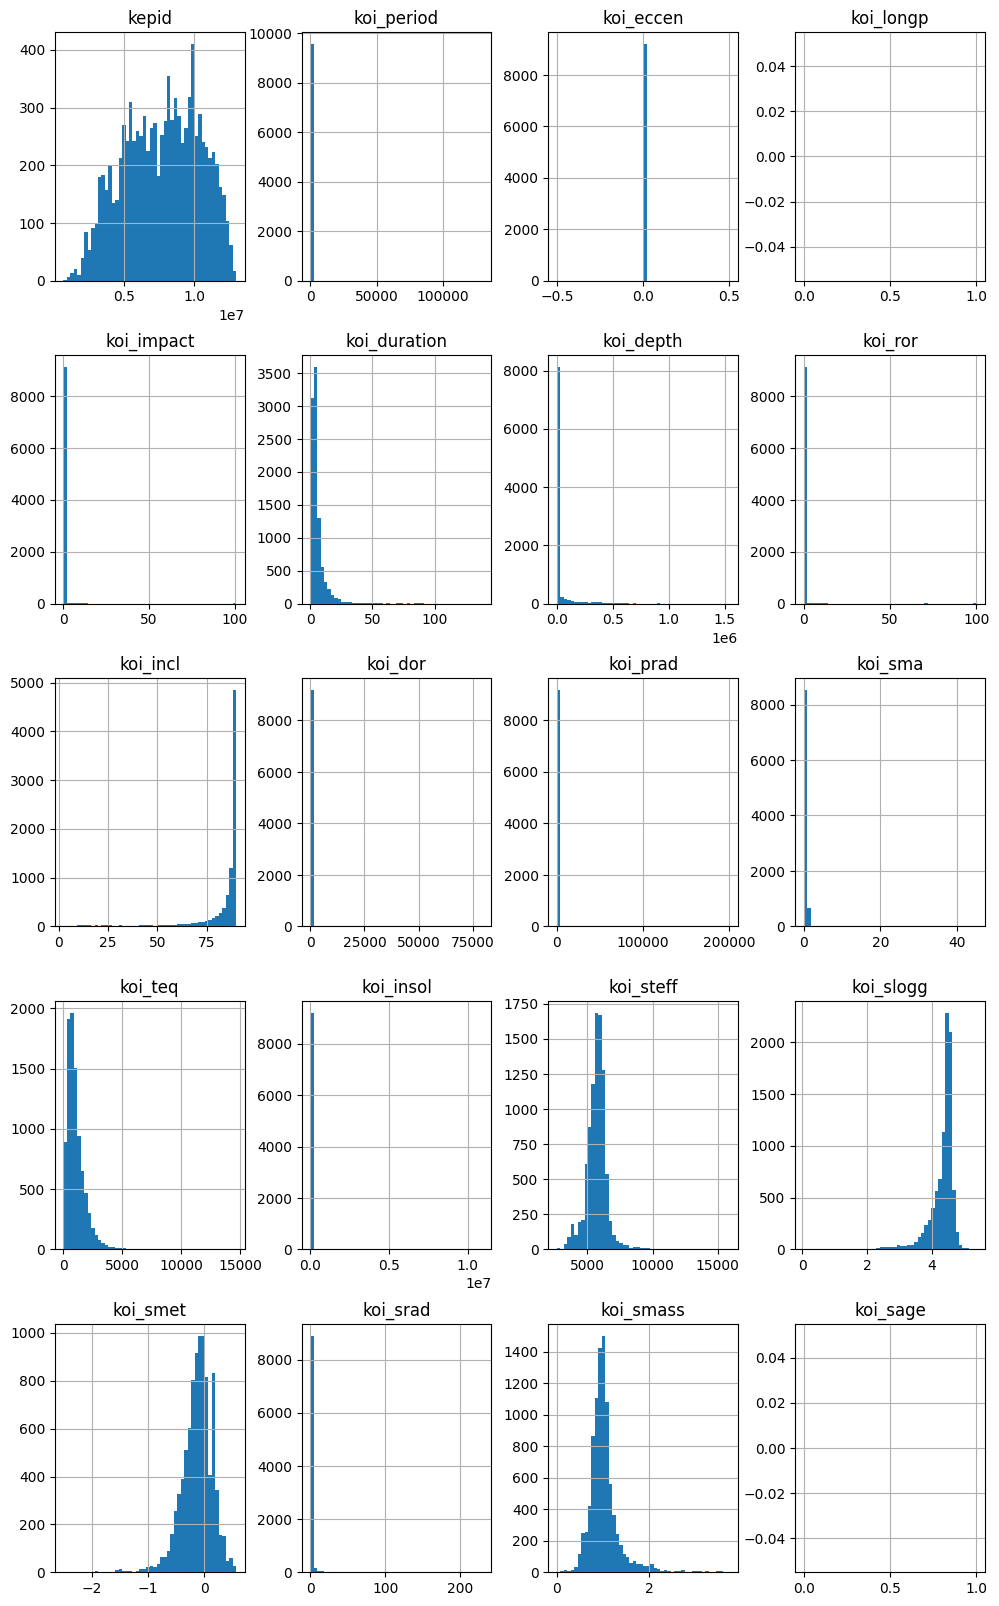

In [10]:
import matplotlib.pyplot as plt 

koi1.hist(bins=50, layout=(5, 4), figsize=(12, 20))
plt.show()

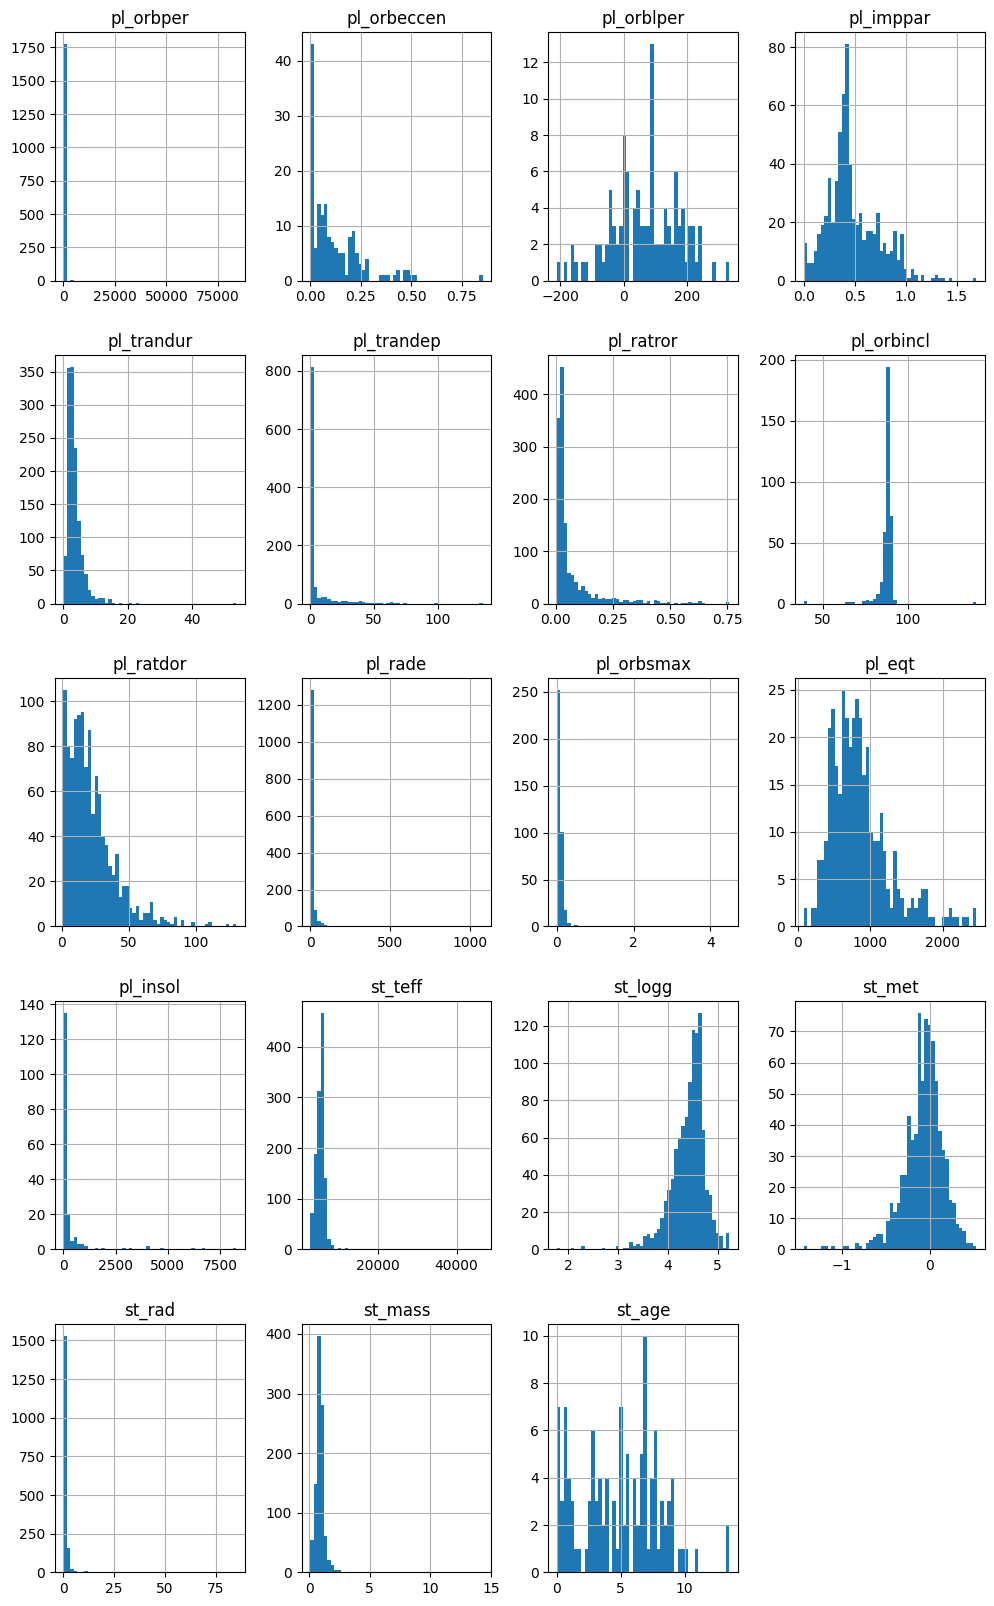

In [11]:
import matplotlib.pyplot as plt 

k2p1.hist(bins=50, layout=(5, 4), figsize=(12, 20))
plt.show()

In [12]:
koi1["koi_disposition"].value_counts()

koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2746
CANDIDATE         1979
Name: count, dtype: int64

In [13]:
k2p1["disposition"].value_counts()

disposition
CANDIDATE         976
CONFIRMED         580
FALSE POSITIVE    242
REFUTED             8
Name: count, dtype: int64

Columns ```kepi``` and ```pl_name``` will be used to group the data, while columns ```koi_disposition``` and ```disposition``` will contitute our labels. For KOI, FALSE POSITIVE objects will be mapped as 0, while CONFIRMED objects will be mapped as 1. For K2P, FALSE POSITIVE + REFUTED objects will be mapped as 0, while CONFIRMED will be mapped as 1. The rest will be extracted as production data, to be tested upon model deployment. Features with more than 50% of the values missing in the training set will be dropped. For the rest, a median imputer will be applied.

Extracting desired labels:

In [14]:
koi_candidates = koi1[koi1["koi_disposition"] == 'CANDIDATE'].copy()
koi_labeled = koi1[koi1["koi_disposition"].isin(['CONFIRMED', 'FALSE_POSITIVE'])].copy()

k2p_candidates = k2p1[k2p1["disposition"] == 'CANDIDATE'].copy()
k2p_labeled = k2p1[k2p1["disposition"].isin(['CONFIRMED', 'FALSE_POSITIVE', 'REFUTED'])].copy()

Mapping labels:

In [15]:
mapper = {"CONFIRMED": 1, "FALSE POSITIVE": 0, "REFUTED": 0}
koi_labeled["label"] = koi_labeled["koi_disposition"].map(mapper)
k2p_labeled["label"] = k2p_labeled["disposition"].map(mapper)

In [16]:
koi_labeled.drop("koi_disposition", axis=1, inplace=True)
k2p_labeled.drop("disposition", axis=1, inplace=True)

Converting units (required for Transit Depth - for KOI it is in ppm, for K2P it is in %):

### Goal of the project  
Task: binary classification -> whether an object is a planet or not  
Metrics: PR AUC, ROC AUC, confusion matrix